# Patch power spectrum → cosmological parameters (TT only)

Companion to `patch_cosmology_fit.ipynb`, restricted to the temperature
(TT) power spectrum only -- no polarization (TE, EE).

Purpose: with tau, Sigma-m_nu, and r fixed (see `cosmo_patch.fitting.camb_cl`),
the temperature power spectrum's dependence on the remaining 5 LambdaCDM
parameters (H0, Omega_b h^2, Omega_c h^2, As, ns) is fully captured by TT
alone -- TE and EE add extra *precision* (breaking some parameter
degeneracies and shrinking error bars) but don't inject any information
those parameters' equations don't already encode through TT. So this
notebook is expected to recover essentially the same best-fit parameters
as the joint TT+TE+EE notebook, just with larger uncertainties -- a
useful sanity check that adding TE/EE isn't *changing* what's being
measured, only sharpening it.

(tau itself is the one parameter TT alone genuinely can't pin down --
it's why it's fixed rather than fit in both notebooks; see the note in
Section 3.)

Requires: `healpy`, `pymaster`, `camb`, `iminuit`, `matplotlib`, and the
`cosmo_patch` module in this repo (`pip install -e .` from the project root).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

from cosmo_patch import patch, power_spectrum, fitting

## 1. Load the data: Planck SMICA half-mission maps + common mask (temperature only)

Same `hm1` x `hm2` cross-spectrum trick as the joint notebook -- their
instrumental noise is independent, so the cross-spectrum is free of noise
bias without a separate debiasing step -- but only the `I_STOKES` field
is needed here.

In [2]:
import os

INPUT_DIR = "input"
NSIDE = 2048
LMAX = 2011  # matches LMAX_TT in the joint notebook, for a direct comparison

FIDUCIAL = dict(H0=67.36, ombh2=0.02237, omch2=0.1200, As=2.1e-9, ns=0.9649)

hm1_path = os.path.join(INPUT_DIR, "COM_CMB_IQU-smica_2048_R3.00_hm1.fits")
hm2_path = os.path.join(INPUT_DIR, "COM_CMB_IQU-smica_2048_R3.00_hm2.fits")
mask_path = os.path.join(INPUT_DIR, "COM_Mask_CMB-common-Mask-Int_2048_R3.00.fits")

# field=0 -> I_STOKES; healpy converts NESTED (as stored) to RING automatically.
map_hm1_t = hp.read_map(hm1_path, field=0) * 1e6  # K_CMB -> uK_CMB
map_hm2_t = hp.read_map(hm2_path, field=0) * 1e6
common_mask = hp.read_map(mask_path, field=0)

cl_fiducial = fitting.camb_cl(**FIDUCIAL, lmax=LMAX)

f_sky = 0.7479


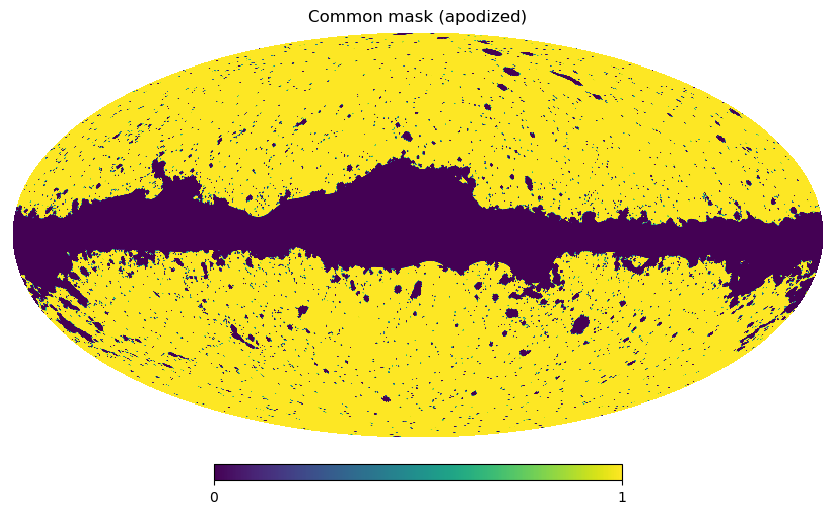

In [3]:
apodized_mask = patch.apodize_mask(common_mask, apodize_deg=0.3, method="C1")

p_t_hm1 = patch.extract_patch(map_hm1_t, apodized_mask)
p_t_hm2 = patch.extract_patch(map_hm2_t, apodized_mask)
print(f"f_sky = {p_t_hm1['f_sky']:.4f}")

hp.mollview(apodized_mask, title="Common mask (apodized)")

## 2. TT power spectrum + covariance (NaMaster)

Cross-spectrum of the two half-mission temperature fields, decoupled
through a single spin0 x spin0 mode-coupling workspace. Beam (5' Gaussian,
SMICA common resolution) and HEALPix pixel-window correction are folded
in. First bandpower (ell=[2,31]) dropped, same as the joint notebook.

In [4]:
beam_fwhm_arcmin = 5.0  # SMICA common resolution
beam_function = hp.gauss_beam(np.radians(beam_fwhm_arcmin / 60), lmax=LMAX)
pixel_window_t = hp.pixwin(NSIDE, lmax=LMAX)

field_t_hm1 = power_spectrum.build_field(
    p_t_hm1, spin=0, beam_function=beam_function, pixel_window_function=pixel_window_t, lmax=LMAX
)
field_t_hm2 = power_spectrum.build_field(
    p_t_hm2, spin=0, beam_function=beam_function, pixel_window_function=pixel_window_t, lmax=LMAX
)

bins = power_spectrum.make_bins(NSIDE, bandpower_width=30, lmax=LMAX)

spec_tt = power_spectrum.compute_power_spectrum(field_t_hm1, bins, field_b=field_t_hm2)
workspace_tt = spec_tt["workspace"]

n_tt = len(spec_tt["ell"]) - 1  # drop bin 0 (ell=[2,31])
ell_tt = spec_tt["ell"][1:1 + n_tt]
cl_data = spec_tt["cl"][1:1 + n_tt]

# hm1 and hm2 have independent noise -- their cross-spectrum above is
# noise-bias-free, but the *covariance* still needs each split's noise
# level, estimated from the half-difference null map (hm1 - hm2)/2, which
# cancels the shared CMB signal and leaves pure noise.
noise_tt = power_spectrum.estimate_noise_cl(
    map_hm1_t, map_hm2_t, apodized_mask, LMAX,
    beam_function=beam_function, pixel_window_function=pixel_window_t,
)

covariance = power_spectrum.compute_gaussian_covariance(
    workspace_tt, field_t_hm1, cl_fiducial["TT"], field_b=field_t_hm2,
    noise_cl_a=noise_tt, noise_cl_b=noise_tt,
)[1:1 + n_tt, 1:1 + n_tt]
errors = power_spectrum.compute_errors(covariance)
cov_inv = np.linalg.inv(covariance)

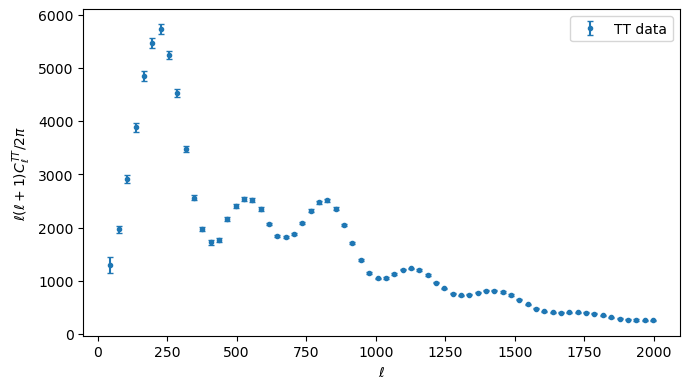

In [5]:
def to_dl(ell, cl):
    return ell * (ell + 1) / (2 * np.pi) * cl

dl_data = to_dl(ell_tt, cl_data)
dl_errors = to_dl(ell_tt, errors)

plt.figure(figsize=(7, 4))
plt.errorbar(ell_tt, dl_data, yerr=dl_errors, fmt="o", ms=3, capsize=2, label="TT data")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell(\ell+1)C_\ell^{TT}/2\pi$")
plt.legend()
plt.tight_layout()

## 3. Fit cosmological parameters (TT only)

Uses `fitting.FitDataTT`/`chi_square_tt`/`fit_parameters_tt` -- a
separate, self-contained TT-only path (not the joint TT+TE+EE functions
with TE/EE left empty). No spin0 x spin2 / spin2 x spin2 workspace, no
TE/EE terms in the chi^2, and no `A_ps_EE` parameter at all -- there's no
EE term here for a point-source amplitude to act on.

tau, Sigma-m_nu, and r stay fixed at the same defaults as the joint
notebook (see `fitting.camb_cl`) -- not because TT can't tolerate a free
tau mechanically, but because tau only enters TT through the combination
`As * exp(-2*tau)`, degenerate with As itself; without independent
large-scale E-mode information there's no way to break that degeneracy
from TT alone. This is the "except tau" caveat: every *other* parameter
has its own distinct imprint on the acoustic peaks (peak positions ->
H0/curvature-like effects, peak height ratios -> Omega_b h^2/Omega_c h^2,
tilt -> ns, overall amplitude -> As once the tau degeneracy is fixed by
hand) and so is expected to converge close to the fiducial values -- tau
is the one parameter that's fundamentally unconstrained by this spectrum
alone, which is exactly why the pipeline fixes it rather than fits it.

Sanity check first: chi^2 at the fiducial parameters should be close to
`n_tt` (66), not wildly off.

In [ ]:
fit_data = fitting.FitDataTT(
    cl_data=cl_data,
    cov_inv=cov_inv,
    workspace_tt=workspace_tt,
    lmax=LMAX,
    n_tt=n_tt,
)

chi2_at_truth = fitting.chi_square_tt(fit_data, **FIDUCIAL, A_ps_TT=50.0)
print(f"chi^2 at fiducial params = {chi2_at_truth:.1f}  (n_bins = {n_tt})")

In [ ]:
initial_guess = dict(
    H0=70.0, ombh2=0.022, omch2=0.11, As=2.0e-9, ns=0.96, A_ps_TT=50.0,
)
bounds = dict(
    H0=(50, 90),
    ombh2=(0.01, 0.03),
    omch2=(0.05, 0.30),
    As=(1e-9, 4e-9),
    ns=(0.9, 1.05),
    A_ps_TT=(0, 200),
)
# Rough expected uncertainty per parameter -- without this, MIGRAD's first
# numerical-gradient estimate can land in a negative-curvature region
# (wildly different parameter scales, e.g. H0~70 vs As~1e-9, condition it
# poorly) and trigger an expensive recovery search. See fit_parameters_tt's
# docstring. compute_minos stays off (the default) -- it's a separate,
# expensive profile-likelihood scan per free parameter that neither
# notebook actually reads (only the HESSE-based `errors` below).
initial_step = dict(
    H0=1.0, ombh2=5e-4, omch2=5e-3, As=5e-11, ns=0.01, A_ps_TT=10.0,
)

result = fitting.fit_parameters_tt(
    fit_data, initial_guess, bounds, initial_step=initial_step
)

print("Converged:", result["valid"])
print("chi^2 at best fit:", result["chi2"])
for name, val in result["best_fit"].items():
    err = result["errors"][name]
    truth = FIDUCIAL.get(name)
    truth_str = f"  (Planck 2018 fiducial: {truth})" if truth is not None else ""
    print(f"  {name} = {val:.5g} +/- {err:.3g}{truth_str}")

## 4. Validate: residuals and best-fit overlay

In [ ]:
best_cosmo = {k: v for k, v in result["best_fit"].items() if k in FIDUCIAL}
best_cl = fitting.camb_cl(**best_cosmo, lmax=LMAX)
ps_tt = fitting.point_source_dl_template(LMAX, result["best_fit"]["A_ps_TT"])

theory_tt = fitting.decouple_theory(workspace_tt, [best_cl["TT"] + ps_tt])[1:1 + n_tt]
ps_tt_binned = fitting.decouple_theory(workspace_tt, [ps_tt])[1:1 + n_tt]

dl_data = to_dl(ell_tt, cl_data)
dl_theory = to_dl(ell_tt, theory_tt)
dl_errors = to_dl(ell_tt, errors)

fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1]})

axes[0].errorbar(ell_tt, dl_data, yerr=dl_errors, fmt="o", ms=3, capsize=2, label="data")
axes[0].plot(ell_tt, dl_theory, "-", label="best-fit theory")
axes[0].plot(ell_tt, to_dl(ell_tt, ps_tt_binned), "k--", lw=1, label=r"$A_{ps}^{TT}$")
axes[0].set_ylabel(r"$\ell(\ell+1)C_\ell^{TT}/2\pi$")
axes[0].legend()

residual = (cl_data - theory_tt) / errors
axes[1].axhline(0, color="k", lw=0.8)
axes[1].plot(ell_tt, residual, "o", ms=3)
axes[1].set_ylabel(r"$(\mathrm{data-theory})/\sigma$")
axes[1].set_xlabel(r"$\ell$")
plt.tight_layout()

## 5. Parameter constraints

Same profile-likelihood contour as the joint notebook. Expect this
contour to be visibly *wider* than the TT+TE+EE version for the same
patch -- TT alone measures the same H0-Omega_c h^2 degeneracy direction,
just with less precision.

In [ ]:
m = result["minuit"]
plt.figure(figsize=(5, 5))
m.draw_mncontour("H0", "omch2", cl=[1, 2])
plt.title(r"$1\sigma$/$2\sigma$ contours: $H_0$ vs $\Omega_c h^2$ (TT only)")
plt.tight_layout()